## Data Retrieval Process

Data is obtained from stooq and stored in the data folder. The structure of the folder is as follows:
- data/daily/us
  - nyse stocks
    - 2
    - 1
  - nasdaq stocks
    - 3
    - 2
    - 1
  - nyse etfs
  - nysemkt stocks
  - nysemkt etfs
  - nasdaq etfs


The following code will only follow on nyse stocks and nasdaq stocks.

Each ticker contains the following columns:
- TICKER
- PER
- DATE
- TIME
- OPEN
- HIGH
- LOW
- CLOSE
- VOL
- OPENINT

Source: https://stooq.com/db/h/

In [9]:
import os
import polars as pl
from concurrent.futures import ThreadPoolExecutor
from datetime import datetime
import pyarrow.dataset as ds

In [ ]:
# paths
load_route = "/Users/alexdomingo/Desktop/Projects/Raw_data/daily/us/"
save_route = "/Users/alexdomingo/Desktop/Projects/Processed_Data/parquet_dataset/"
meta_route = "/Users/alexdomingo/Desktop/Projects/Processed_Data/_metadata/"
log_path = os.path.join(meta_route, "updates.parquet")

folders = ["nyse stocks", "nasdaq stocks"]

os.makedirs(meta_route, exist_ok=True)

cols = ["ticker", "per", "date", "time", "open", "high", "low", "close", "vol", "openint"]


# =========================
# Utils
# =========================

def process_file(args, last_date=None):
    file_path, folder = args
    try:

        df = pl.read_csv(
            file_path,
            has_header=True,
            schema_overrides={
                "<DATE>": pl.Utf8,
                "<VOL>": pl.Float64,
                "<OPEN>": pl.Float64,
                "<HIGH>": pl.Float64,
                "<LOW>": pl.Float64,
                "<CLOSE>": pl.Float64,
            }
        )
        if df.height == 0:
            return None
        
        df.columns = cols  # rename AFTER reading

        df = (
            df
            .with_columns([
                pl.lit(folder.replace(" stocks", "")).alias("exchange"),
                pl.col("ticker").str.replace(r"\.US$", ""),
                pl.col("date").cast(pl.Utf8).str.strptime(pl.Date, "%Y%m%d")
            ])
        )

        # only apply filter if updating
        if last_date is not None:
            df = df.filter(pl.col("date") > last_date)

        df = (
            df
            .with_columns(pl.col("date").dt.year().alias("year"))
            .drop(["per", "time", "openint"])
            .select(['ticker','exchange','date','year','open','high','low','close','vol'])
        )

        return df

    except Exception as e:
            # log and skip bad files
            print(f"Skipping file: {file_path} | Error: {e}")
            return None


def collect_files():
    file_tasks = []
    for folder in folders:
        folder_path = os.path.join(load_route, folder)
        for root, _, files in os.walk(folder_path):
            for file in files:
                if file.endswith(".txt"):
                    file_tasks.append((os.path.join(root, file), folder))
    return file_tasks


def parallel_process(file_tasks, last_date=None):
    max_workers = min(8, os.cpu_count())

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        dfs = list(executor.map(lambda x: process_file(x, last_date), file_tasks))

    # remove failed/empty results
    dfs = [df for df in dfs if df is not None]

    if len(dfs) == 0:
        return pl.DataFrame()

    return pl.concat(dfs)


def update_log(new_df, file_tasks, mode):
    new_log = pl.DataFrame({
        "update_time": [datetime.now()],
        "rows_added": [new_df.height],
        "min_date": [new_df.select(pl.col("date").min()).item()],
        "max_date": [new_df.select(pl.col("date").max()).item()],
        "files_processed": [len(file_tasks)],
        "mode": [mode]
    })

    if os.path.exists(log_path):
        log_df = pl.read_parquet(log_path)
        log_df = pl.concat([log_df, new_log])
    else:
        log_df = new_log

    log_df.write_parquet(log_path)


# =========================
# Initial build pipeline
# =========================

def init_pipeline():
    print("Running INITIAL BUILD...")

    file_tasks = collect_files()
    df = parallel_process(file_tasks)

    df.write_parquet(save_route, partition_by=["exchange", "year"])

    update_log(df, file_tasks, "init")

    print("Initial dataset created")


# =========================
# Update pipeline
# =========================

def update_pipeline():
    print("Running UPDATE...")

    log_df = pl.read_parquet(log_path)
    last_date = log_df.select(pl.col("max_date").max()).item()

    file_tasks = collect_files()
    new_df = parallel_process(file_tasks, last_date)

    if new_df.height == 0:
        print("No new data found. Dataset is up to date.")
        return

    years = new_df.select(pl.col("year").unique()).to_series().to_list()

    for year in years:
        existing = pl.read_parquet(save_route).filter(pl.col("year") == year)

        updated = pl.concat([
            existing,
            new_df.filter(pl.col("year") == year)
        ]).unique(subset=["ticker", "date"])

        updated.write_parquet(save_route, partition_by=["exchange", "year"])

    update_log(new_df, file_tasks, "update")

    print("Dataset updated")


# =========================
# Execute pipeline
# =========================

if not os.path.exists(log_path):
    init_pipeline()
else:
    update_pipeline()

Running INITIAL BUILD...
Skipping file: /Users/alexdomingo/Desktop/Projects/Raw_data/daily/us/nyse stocks/1/gled.us.txt | Error: empty CSV
Skipping file: /Users/alexdomingo/Desktop/Projects/Raw_data/daily/us/nyse stocks/1/gledu.us.txt | Error: empty CSV
Skipping file: /Users/alexdomingo/Desktop/Projects/Raw_data/daily/us/nyse stocks/1/bwiv.us.txt | Error: empty CSV
Skipping file: /Users/alexdomingo/Desktop/Projects/Raw_data/daily/us/nyse stocks/1/kcacu.us.txt | Error: empty CSV
Skipping file: /Users/alexdomingo/Desktop/Projects/Raw_data/daily/us/nyse stocks/1/kcac.us.txt | Error: empty CSV
Skipping file: /Users/alexdomingo/Desktop/Projects/Raw_data/daily/us/nyse stocks/2/mtalu.us.txt | Error: empty CSV
Skipping file: /Users/alexdomingo/Desktop/Projects/Raw_data/daily/us/nyse stocks/2/tradu.us.txt | Error: empty CSV
Skipping file: /Users/alexdomingo/Desktop/Projects/Raw_data/daily/us/nyse stocks/2/trad.us.txt | Error: empty CSVSkipping file: /Users/alexdomingo/Desktop/Projects/Raw_data/

In [11]:
# Load Data to verify
# Use pyarrow dataset to read partitioned parquet efficiently

dataset = ds.dataset("/Users/alexdomingo/Desktop/Projects/Processed_Data/parquet_dataset/")
df = dataset.to_table().to_pandas()
df.head()

,ticker,exchange,date,year,open,high,low,close,vol
0,GT,nasdaq,1970-01-02,1970,3.3224,3.4290,3.2687,3.4023,36264.0
1,GT,nasdaq,1970-01-05,1970,3.3844,3.3844,3.2953,3.3310,26498.0
2,GT,nasdaq,1970-01-06,1970,3.2778,3.2778,3.1887,3.2421,68487.0
3,GT,nasdaq,1970-01-07,1970,3.2244,3.2244,3.1620,3.1976,25597.0
4,GT,nasdaq,1970-01-08,1970,3.1976,3.2244,3.1620,3.1887,28293.0


In [ ]:
# Count tickers
tickers = df["ticker"].unique()
print(len(tickers))

8131


In [10]:
# Load log to verify
data_log = ds.dataset("/Users/alexdomingo/Desktop/Projects/Processed_Data/_metadata/")
data_log = data_log.to_table().to_pandas()
data_log.head()

,update_time,rows_added,min_date,max_date,files_processed,mode
0,2026-03-22 21:24:03.344483,19417640,1962-01-02,2026-03-20,8174,init


In [ ]:
tesla = final_df[final_df["ticker"] == "TSLA"]
tesla.head()

,ticker,exchange,date,year,open,high,low,close,vol
15121935,TSLA,nasdaq,2010-06-28,2010,1.13333,1.13333,1.13333,1.13333,0.0
15121936,TSLA,nasdaq,2010-06-29,2010,1.26667,1.66667,1.16933,1.59267,281749140.0
15121937,TSLA,nasdaq,2010-06-30,2010,1.71933,2.02800,1.55333,1.58867,257915910.0
15121938,TSLA,nasdaq,2010-07-01,2010,1.66667,1.72800,1.35133,1.46400,123447945.0
15121939,TSLA,nasdaq,2010-07-02,2010,1.53333,1.54000,1.24733,1.28000,77127105.0


<Axes: xlabel='date'>

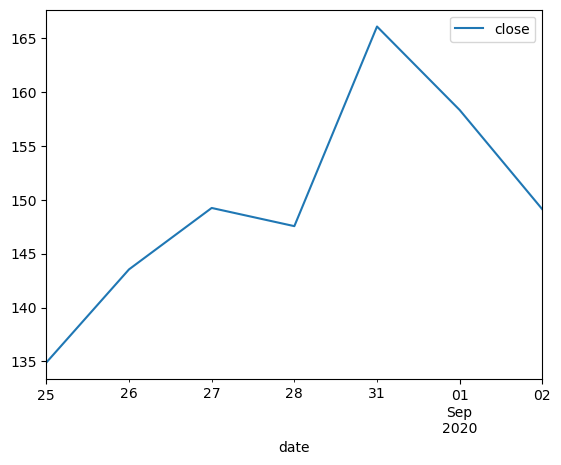

In [ ]:
start_date = pd.Timestamp("2020-08-25")
end_date = pd.Timestamp("2020-09-02")

tesla_2020 = tesla[
    (tesla["year"] == 2020) &
    (tesla["date"] >= start_date) &
    (tesla["date"] <= end_date)
]
tesla_2020.plot(x="date", y="close")

## Archive

### Pandas Load CSV save as csv

In [56]:

load_route = "/Users/alexdomingo/Desktop/Projects/data/daily/us/"
save_route="/Users/alexdomingo/Desktop/Projects/data/"
folders = ["nyse stocks", "nasdaq stocks"]

cols = ["ticker", "per", "date", "time", "open", "high", "low", "close", "vol", "openint"] 
drop_cols = ["per", "time", "openint"]
dfs = []

for folder in folders:
    folder_path = os.path.join(load_route, folder)
    
    for root, dirs, files in os.walk(folder_path):
        for file in files:
            if file.endswith(".txt"):
                file_path = os.path.join(root, file)
                
                df = pd.read_csv(file_path, names=cols, header=0)
                df["exchange"] = folder.replace(" stocks", "")
                df["ticker"] = df["ticker"].str.replace(".US", "", regex=False)
                df['date'] = pd.to_datetime(df['date'], format='%Y%m%d')
                df['year'] = df['date'].dt.year

                # openint (Open Interest) is not relevant for stocks; per (period) is always daily; time is always 0000 so they are not loaded.
                df = df.drop(columns=drop_cols)

                # Reorder columns
                df = df[['ticker','exchange', 'date', 'year', 'open', 'high', 'low', 'close', 'vol']]
                
                dfs.append(df)

final_df = pd.concat(dfs, ignore_index=True)

#Save file with todays date (date at which data was retrieved)
date = pd.to_datetime("today").strftime("%Y%m%d")
final_df.to_csv(f"{save_route}daily_stock_data_{date}.csv", index=False)

/var/folders/2x/jmz0l07s05vbhz_cdl7wpbg40000gp/T/ipykernel_1055/1596986797.py:31: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  final_df = pd.concat(dfs, ignore_index=True)


### Pandas Parallel CSV -> Parquet

In [ ]:
import os
import polars as pl
from concurrent.futures import ThreadPoolExecutor
from datetime import datetime

In [ ]:
def process_file(args):
    file_path, folder = args

    cols = ["ticker", "per", "date", "time", "open", "high", "low", "close", "vol", "openint"] 
    drop_cols = ["per", "time", "openint"]

    df = pd.read_csv(file_path, names=cols, header=0)
    df["exchange"] = folder.replace(" stocks", "")
    df["ticker"] = df["ticker"].str.replace(".US", "", regex=False)
    df['date'] = pd.to_datetime(df['date'], format='%Y%m%d')
    df['year'] = df['date'].dt.year

    df = df.drop(columns=drop_cols)
    df = df[['ticker','exchange', 'date', 'year', 'open', 'high', 'low', 'close', 'vol']]
    
    return df

In [ ]:
# Collect file paths and folders for multitasking

load_route = "/Users/alexdomingo/Desktop/Projects/data/daily/us/"
save_route="/Users/alexdomingo/Desktop/Projects/data/"
folders = ["nyse stocks", "nasdaq stocks"]

file_tasks = []

for folder in folders:
    folder_path = os.path.join(load_route, folder)
    
    for root, _, files in os.walk(folder_path):
        for file in files:
            if file.endswith(".txt"):
                file_tasks.append((os.path.join(root, file), folder))

In [ ]:
max_workers = min(8, os.cpu_count())

with ThreadPoolExecutor(max_workers=max_workers) as executor:
    dfs = list(executor.map(process_file, file_tasks))

final_df = pd.concat(dfs, ignore_index=True)

date = pd.to_datetime("today").strftime("%Y%m%d")
final_df.to_parquet(f"{save_route}daily_stock_data_{date}.parquet", index=False)

/var/folders/2x/jmz0l07s05vbhz_cdl7wpbg40000gp/T/ipykernel_1055/2982742567.py:6: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  final_df = pd.concat(dfs, ignore_index=True)


### (1) YFinance Ticker data

In [7]:
# Load dependencies
import yfinance as yf
import pandas as pd
import tqdm
import logging

In [3]:
# Load list of tickers
tkr_df = pd.read_csv('./Data/NasdaqListed.txt', sep='|')
# tkr_df.head()

In [ ]:
# keep only stocks & ticker column
tickers = (
    tkr_df
    .loc[tkr_df["ETF"] == "N", "Symbol"]
    .dropna()
    .astype('str')
    .str.strip() #remove white spaces
    .unique()
    .tolist()
)
print(type(tickers))
print(tickers[:20])

<class 'list'>
['AACB', 'AACBR', 'AACBU', 'AACG', 'AAL', 'AAME', 'AAOI', 'AAON', 'AAPG', 'AAPL', 'AARD', 'ABAT', 'ABCL', 'ABEO', 'ABLV', 'ABLVW', 'ABNB', 'ABOS', 'ABP', 'ABPWW']


In [24]:

existing = data.columns.get_level_values(1).unique().tolist()

print(existing)


['META']


In [ ]:
# ---------------------------------------------------
# Utils
# ---------------------------------------------------

'''
Donwload data process:
1. Load existing data (if any)
2. Load ticker list for largest version
3. Separate tickers into:
    New ticker
    Old tickers
    Deleted tickers
4. For deleted tickers, check against cik to see if name changed or if it was removed/delisted
5. For new tickers download full history
6. For old_tickers check last availalbe date and download and append the remaining data
7. Merge new data with existing data
8. Save updated data to parquet
'''

def load_data(path):
    if path.exists():
        return pd.read_parquet(path)
    
    return pd.DataFrame()
 
def split_tickers(df, tkr_df):
    '''
    Splits tickers into two lists:
    - old_tkrs: tickers that already have data in the existing dataframe and will use last avaialble date as start date for downloading new data
    - new_tkrs: tickers that do not have data in the existing dataframe and need to be downloaded fully
    - del_tkrs: tickers that are in the existing dataframe but not in the new ticker list, need to check if they were delisted or just changed name
    '''
    if df.empty:
        return [], new_tkrs, []
    
    # version for json tkr file
    json_vers = pd.to_datetime('today').date().strftime('%Y%m%d')
    tkr_df = tkr_df.loc[tkr_df['Version'] == json_vers]['cik', 'ticker' ]

    # Filter out tickers already existing in the df
    existing = set(df.columns.get_level_values(1).unique().tolist())

    # Fitler out new tickers into new - name change or ipo - and deleted - 


    requested = set(tkrs)

    old_tkrs = list(existing & requested)
    new_tkrs = list(requested - existing)

    return old_tkrs, new_tkrs

def get_start_date(df):
    '''
    For old_tickers finds last available existing date to use as start date for updating data. New tickers use start_date_0
    '''
    if tkr in df.columns:
        return df[tkr].last_valid_index() + 1
    else:
        return start_date_0
    
def download_data(tkrs, start_date , end_date, freq):
    
    logging.info(f"Downloading data for {len(tkrs)} tickers from {start_date} to {end_date} with frequency:{freq}")
    
    data = yf.download(
        tkr,
        start = start_date,
        end = end_date,
        interval = '1d',
        auto_adjust=True #applies adjustment for dividends & splits
    ) 

    data= data.loc[:, pd.IndexSlice[["Open", "Close"], :]]

    return data 

def merge_data(old_df, new_df);
    if old_df.empty:
        return new_df
    else:
        combined_df = pd.concat([old_df, new_df], axis=1)
        combined_df = combined_df[~combined_df.index.duplicated(keep='last')]
        return combined_df

def update_data(tkrs, start_date, freq, path):

    logging.info("Loading data")
    df = load_data(path)

    start_date = get_start_date(df,start_date_0)
    end_date = pd.to_datetime('today').date()
    if start_date >= end_date:
        logging.info("Data is already up to date")
        return df
    
    new_data = download_data(tkrs, start_date, end_date, freq)
    updated_df = merge_data(df, new_data)
    logging.info("Updated daata, saving to parquet")
    updated_df.to_parquet(path, engine='pyarrow')


In [9]:
# ----------------------------------------
# Variables
# ----------------------------------------
start_date_0 = "2010-01-01" #approximate date when disclosures began
freq = "daily" # Options: "daily", "weekly", "monthly"
# data_path = './Data/stock_data.parquet'

# update_data(tickers, start_date_0, freq, data_path)

In [29]:

# ----------------------------------------
# Variables
# ----------------------------------------
start_date_0 = "2010-01-01" #approximate date when disclosures began
end_date = "2026-01-31"
freq = "daily" # Options: "daily", "weekly", "monthly"
data_path = './Data/stock_data.parquet'

test = pd.to_datetime('today').date()
print(test)


2026-03-08


In [30]:
# OLD WORKING CODE

#download data for all tickers using a loop

# df = load_parquet('./Data/stock_data.parquet')
df = pd.DataFrame() 
if df.empty:
    df = pd.DataFrame()
else:
    df = df.copy()

tickers = ['ASTR']
for tkr in tqdm.tqdm(tickers, desc = "Downloading"):
    logging.info(f"Checking last available date for {tkr}")
    start_date_1 = df[tkr].last_valid_index() +1 if tkr in df.columns else start_date_0


    logging.info(f"Downloading {tkr})")
    data = yf.download(
        tkr,
        start = start_date_0,
        end = pd.to_datetime('today').date(),
        interval = '1d',
        auto_adjust=True #applies adjustment for dividends & splits
    )

    if data.empty:
        logging.info(f"No data found for {tkr}")
        continue

    data= data.loc[:, pd.IndexSlice[["Open", "Close"], :]]
    # final_df = pd.concat([final_df,data], axis = 1, join = 'outer')

print(data)


Downloading:   0%|          | 0/1 [00:00<?, ?it/s]ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: ASTR"}}}
ERROR:yfinance:$ASTR: possibly delisted; no timezone found
[*********************100%***********************]  1 of 1 completed
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['ASTR']: possibly delisted; no timezone found
Downloading: 100%|██████████| 1/1 [00:00<00:00,  1.47it/s]

Empty DataFrame
Columns: [(Adj Close, ASTR), (Close, ASTR), (High, ASTR), (Low, ASTR), (Open, ASTR), (Volume, ASTR)]
Index: []


In [28]:
data.head()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,ASTR,ASTR,ASTR,ASTR,ASTR,ASTR
Date,,,,,,


In [ ]:
final_df.to_parquet('stock_data.parquet', engine ='pyarrow')
df = load_parquet('./Data/stock_data.parquet')